In [38]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
%pip install matplotlib seaborn scikit-learn imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

import seaborn as sns

import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import imblearn

In [41]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# importing the dataset which is in csv file

data = pd.read_excel(r"C:\Users\My world\Documents\smartlender\dataset\loan_prediction.xlsx")

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


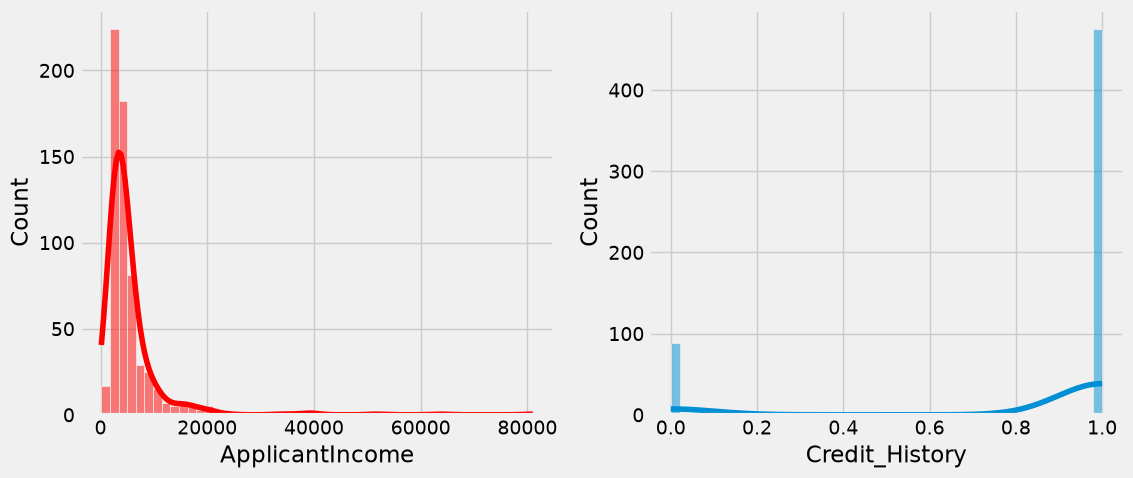

In [43]:
# plotting the using distplot

plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data['ApplicantIncome'], kde=True, color='r')

plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)

plt.show()

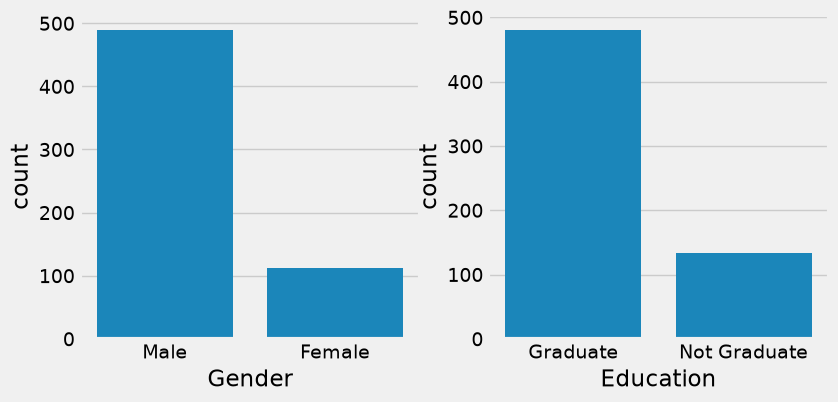

In [44]:
plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
sns.countplot(x=data['Gender'])

plt.subplot(1,4,2)
sns.countplot(x=data['Education'])
plt.show()

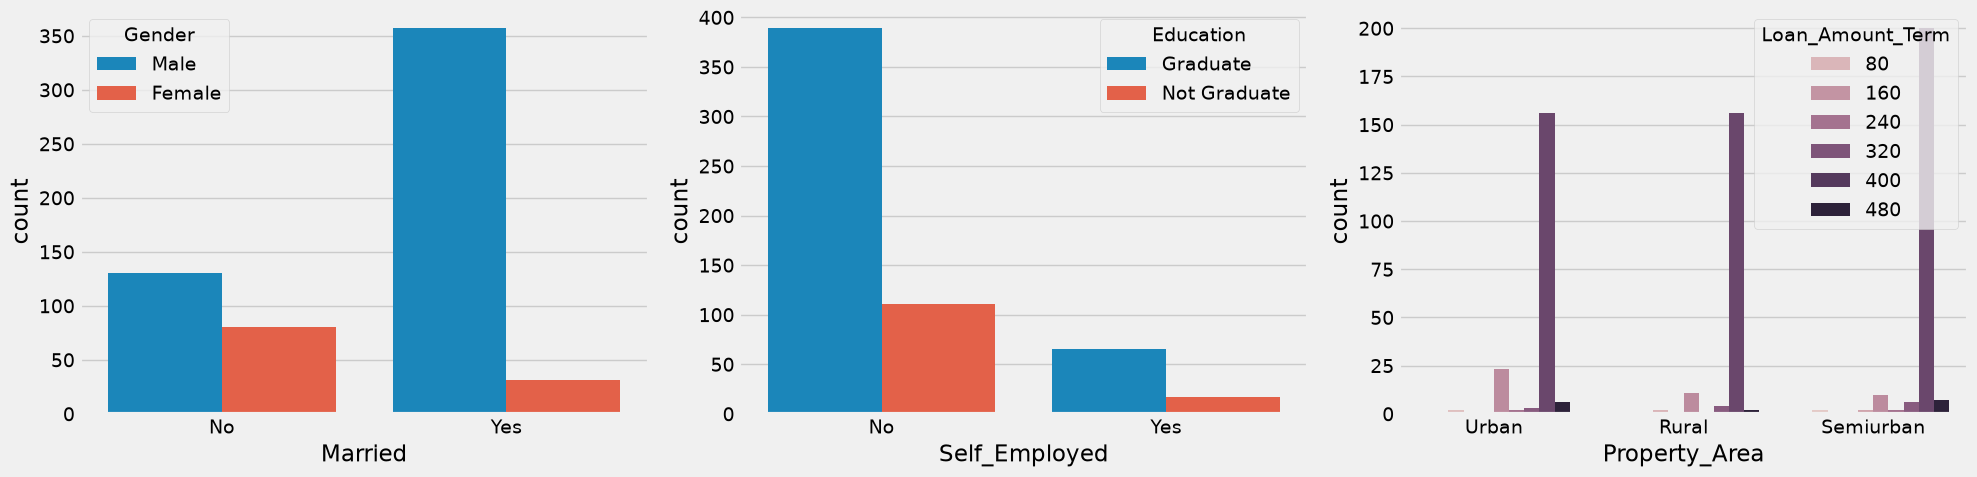

In [45]:
# visualising two columns against each other

plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x=data['Married'], hue=data['Gender'])

plt.subplot(132)
sns.countplot(x=data['Self_Employed'], hue=data['Education'])

plt.subplot(133)
sns.countplot(x=data['Property_Area'], hue=data['Loan_Amount_Term'])

plt.tight_layout()
plt.show()

C:\Users\My world\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 15.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\My world\AppData\Roaming\Python\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 38.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


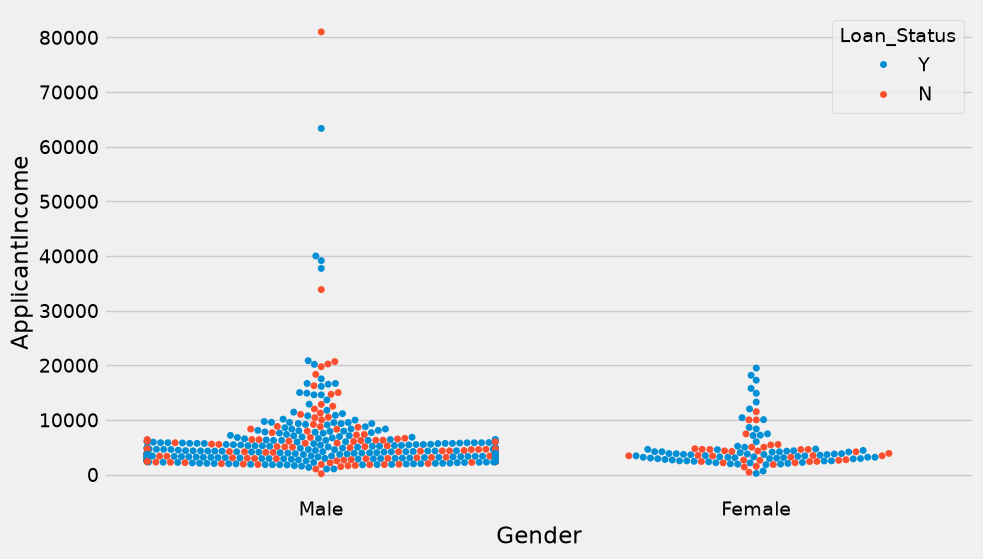

In [46]:
# visualized based gender and income what would be the application status

plt.figure(figsize=(10,6))

sns.swarmplot(
    data=data,
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status'
)

plt.show()

In [47]:
%pip install jupyterthemes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import jupyterthemes as jt

In [49]:
# finding the sum of null values in each column

data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [50]:
# Handling categorical values

data['Gender'] = data['Gender'].map({'Female':1,'Male':0})

In [51]:
data['Property_Area'] = data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})

In [52]:
data['Married'] = data['Married'].map({'Yes':1,'No':0})

In [53]:
data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})

In [54]:
data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

In [55]:
data['Self_Employed'] = data['Self_Employed'].map({'Yes':1,'No':0})

In [56]:
# replacing + with space

data['Dependents'] = data['Dependents'].str.replace('+','',regex=False)

In [57]:
data['Dependents'] = data['Dependents'].astype(float)

In [58]:
# finding the sum of null values in each column

data.isnull().sum()

Loan_ID                0
Gender                13
Married                3
Dependents           563
Education              0
Self_Employed         32
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            22
Loan_Amount_Term      14
Credit_History        50
Property_Area          0
Loan_Status            0
dtype: int64

In [59]:
# filling missing values

data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

In [60]:
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

In [61]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

In [62]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

In [63]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])

In [64]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

In [65]:
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [66]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [67]:
# getting the total info of the data after performing categorical to numerical and replacing missing values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    float64
 2   Married            614 non-null    float64
 3   Dependents         614 non-null    float64
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    float64
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(8), int64(4), object(1)
memory usage: 62.5+ KB


In [68]:
# changing the datatype of each float column to int

data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            614 non-null    object
 1   Gender             614 non-null    int64 
 2   Married            614 non-null    int64 
 3   Dependents         614 non-null    int64 
 4   Education          614 non-null    int64 
 5   Self_Employed      614 non-null    int64 
 6   ApplicantIncome    614 non-null    int64 
 7   CoapplicantIncome  614 non-null    int64 
 8   LoanAmount         614 non-null    int64 
 9   Loan_Amount_Term   614 non-null    int64 
 10  Credit_History     614 non-null    int64 
 11  Property_Area      614 non-null    int64 
 12  Loan_Status        614 non-null    int64 
dtypes: int64(12), object(1)
memory usage: 62.5+ KB


In [77]:
from pathlib import Path
import pickle
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------
# 1. FEATURE ENGINEERING
# --------------------------------------------------

data['TotalIncome'] = (
    data['ApplicantIncome'] + data['CoapplicantIncome']
)

data['IncomeToLoanRatio'] = (
    data['TotalIncome'] /
    data['LoanAmount'].replace(0, np.nan)
)

data['IncomeToLoanRatio'] = (
    data['IncomeToLoanRatio']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

data['LoanAmountLog'] = np.log1p(data['LoanAmount'])

data['TotalIncomeLog'] = np.log1p(data['TotalIncome'])


# --------------------------------------------------
# 2. PREPARE FEATURES AND TARGET
# --------------------------------------------------

X = data.drop(
    ['Loan_ID', 'Loan_Status'],
    axis=1
)

y = data['Loan_Status']


# --------------------------------------------------
# 3. CHECK FEATURE ORDER
# --------------------------------------------------

print("Model Features:")

for i, column in enumerate(X.columns):
    print(i, column)


# --------------------------------------------------
# 4. TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# --------------------------------------------------
# 5. CREATE RANDOM FOREST MODEL
# --------------------------------------------------

best_model = RandomForestClassifier(

    n_estimators=800,

    max_depth=10,

    min_samples_leaf=4,

    max_features=0.7,

    class_weight='balanced_subsample',

    random_state=42
)


# --------------------------------------------------
# 6. TRAIN MODEL
# --------------------------------------------------

best_model.fit(X_train, y_train)


# --------------------------------------------------
# 7. TEST MODEL
# --------------------------------------------------

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# --------------------------------------------------
# 8. CHECK MODEL CLASSES
# --------------------------------------------------

print("\nModel Classes:")

print(best_model.classes_)


# --------------------------------------------------
# 9. SAVE MODEL
# --------------------------------------------------

output_dir = Path(
    r'C:\Users\My world\Documents\smartlender\final model'
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

model_path = output_dir / 'randomforest.pkl'

with open(model_path, 'wb') as file:

    pickle.dump(
        best_model,
        file
    )


print("\nModel Saved Successfully")

print("Location:", model_path)


# --------------------------------------------------
# 10. SAVE FEATURE NAMES
# --------------------------------------------------

feature_path = output_dir / 'feature_names.pkl'

with open(feature_path, 'wb') as file:

    pickle.dump(
        list(X.columns),
        file
    )


print("Feature Names Saved Successfully")

print("\nFinal Features:")

print(list(X.columns))

Model Features:
0 Gender
1 Married
2 Dependents
3 Education
4 Self_Employed
5 ApplicantIncome
6 CoapplicantIncome
7 LoanAmount
8 Loan_Amount_Term
9 Credit_History
10 Property_Area
11 TotalIncome
12 IncomeToLoanRatio
13 LoanAmountLog
14 TotalIncomeLog

Training Shape: (491, 15)
Testing Shape: (123, 15)

Model Accuracy: 0.8861788617886179

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        38
           1       0.92      0.92      0.92        85

    accuracy                           0.89       123
   macro avg       0.87      0.87      0.87       123
weighted avg       0.89      0.89      0.89       123


Confusion Matrix:
[[31  7]
 [ 7 78]]

Model Classes:
[0 1]

Model Saved Successfully
Location: C:\Users\My world\Documents\smartlender\final model\randomforest.pkl
Feature Names Saved Successfully

Final Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'Coapplica